## **Aluno**: Luis Eduardo Alencar Melo
## **Pós Graduação:** Inteligência Artificial
## **Professor:** Prof. Dr. Luís Gustavo Mota Souza
## **Atividade:** Avaliativa

## Resolução da Atividade

A seguir, apresenta-se a resolução da atividade avaliativa. O código está escrito em **Python**, utilizando as bibliotecas `numpy` e `matplotlib`.

### Bibliotecas Utilizadas

  * **`numpy`**: É a biblioteca fundamental para computação científica em Python. Ela fornece suporte para arrays e matrizes multidimensionais de alta performance, juntamente com uma vasta coleção de funções matemáticas para operar nesses arrays. No código, `numpy` (apelidada de `np`) é essencial para a manipulação de vetores e matrizes, cálculos de covariância, e geração de números aleatórios de distribuições específicas.

  * **`matplotlib.pyplot`**: É uma coleção de funções que fazem o `matplotlib` funcionar de forma semelhante ao MATLAB. `matplotlib` é uma biblioteca de visualização de dados abrangente para criar gráficos estáticos, animados e interativos em Python. No código, `matplotlib.pyplot` (apelidada de `plt`) é utilizada para criar os gráficos de dispersão (*scatter plots*), permitindo a visualização das amostras de dados geradas.

### Setup Inicial

Primeiro, importamos as bibliotecas necessárias e definimos os parâmetros base do problema, que serão utilizados ao longo de toda a resolução.

```python
import numpy as np
import matplotlib.pyplot as plt

# Definição dos parâmetros base do problema
# (Exemplo: parâmetros a serem inseridos aqui)
parametro_1 = 10
parametro_2 = 5.5
```

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# --- PARÂMETROS GLOBAIS DA QUESTÃO ---

# Vetor de médias (esperanças) teóricas das variáveis aleatórias X e Y
# E[X] = 1 e E[Y] = 2
mu_teorico = np.array([1, 2])

# Matriz de covariância teórica de X e Y
# Var(X)=4, Var(Y)=9, Cov(X,Y)=0
C_XY_teorica = np.array([[4, 0],
                         [0, 9]])

# Número de amostras a serem geradas
N = 5000

# Semente para o gerador de números aleatórios, garantindo a reprodutibilidade dos resultados
np.random.seed(42)

### (a) Determinar a matriz de correlação R_XY teórica correspondente.

> **Comentários sobre a resolução:**
> A matriz de correlação ($R_{XY}$) pode ser obtida a partir da matriz de covariância ($C_{XY}$) e do vetor de médias ($\mu$) através da seguinte relação:
>
> $$R_{XY} = C_{XY} + \mu\mu^T$$
>
> Onde $\mu\mu^T$ representa o produto externo do vetor de médias. O código abaixo implementa exatamente este cálculo.

In [15]:
# Para o cálculo do produto externo, o vetor de médias precisa ser um vetor coluna.
mu_coluna = mu_teorico.reshape(2, 1)

# Cálculo do produto externo do vetor de médias
mu_mu_T = mu_coluna @ mu_coluna.T

# Cálculo da matriz de correlação teórica
R_XY_teorica = C_XY_teorica + mu_mu_T

print("--- Resolução (a) ---")
print("Matriz de Correlação Teórica (R_XY):")
print(R_XY_teorica)

--- Resolução (a) ---
Matriz de Correlação Teórica (R_XY):
[[ 5  2]
 [ 2 13]]


### (b) Gerar uma amostra S = {($x_k, y_k$)}, k = 1,...,N = 5000, que tenha as características descritas no enunciado da questão.

> **Comentários sobre a resolução:**
> Para gerar uma amostra de uma distribuição Gaussiana multivariada, utilizamos a função `numpy.random.multivariate_normal`. Ela recebe como entrada o vetor de médias teóricas, a matriz de covariância teórica e o número de amostras desejado (N). O resultado é uma matriz `S` de dimensões (5000, 2), onde cada linha é um par ($x_k, y_k$).

In [5]:
# Geração da amostra S com N=5000 pontos
S = np.random.multivariate_normal(mu_teorico, C_XY_teorica, N)

print("--- Resolução (b) ---")
print(f"Amostra S com {N} pontos foi gerada com sucesso.")
print(f"Dimensões da matriz S: {S.shape}")
print("\nExemplo das 5 primeiras amostras (x_k, y_k):")
print(S[:5].round(4))

--- Resolução (b) ---
Amostra S com 5000 pontos foi gerada com sucesso.
Dimensões da matriz S: (5000, 2)

Exemplo das 5 primeiras amostras (x_k, y_k):
[[0.7235 3.4901]
 [4.0461 3.9431]
 [0.5317 1.2975]
 [2.5349 6.7376]
 [2.0851 0.5916]]


### (c) Mostrar o gráfico de dispersão para a amostra gerada.

> **Comentários sobre a resolução:**
> Um gráfico de dispersão (*scatter plot*) é a melhor forma de visualizar a distribuição dos dados gerados. Cada ponto no gráfico corresponde a um par ($x_k, y_k$) da amostra `S`. A nuvem de pontos deve se concentrar em torno da média teórica `(1, 2)`. Como a covariância é nula, a elipse formada pelos pontos não terá rotação. A variância maior em Y (`9`) do que em X (`4`) fará com que a nuvem seja mais "esticada" na vertical.


--- Resolução (c) ---


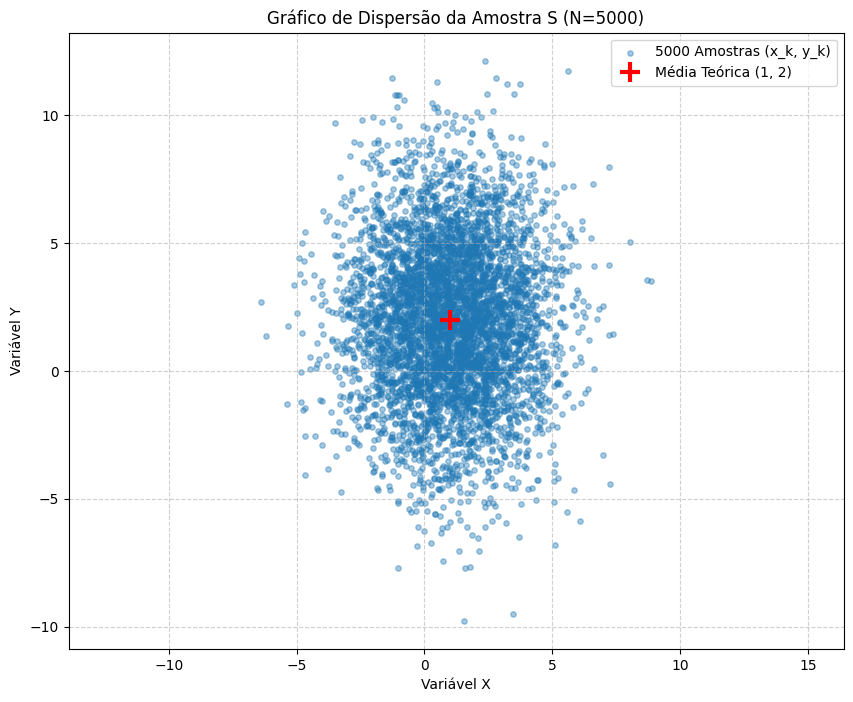

In [6]:
print("\n--- Resolução (c) ---")

# Extraindo as colunas x e y da amostra S
x_k = S[:, 0]
y_k = S[:, 1]

plt.figure(figsize=(10, 8))
plt.scatter(x_k, y_k, alpha=0.4, s=15, label=f'{N} Amostras (x_k, y_k)')
# Marcador para a média teórica
plt.plot(mu_teorico[0], mu_teorico[1], 'r+', markersize=15, markeredgewidth=3, label=f'Média Teórica ({mu_teorico[0]}, {mu_teorico[1]})')

plt.title(f'Gráfico de Dispersão da Amostra S (N={N})')
plt.xlabel('Variável X')
plt.ylabel('Variável Y')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.axis('equal') # Garante que a escala dos eixos seja a mesma para uma visualização correta
plt.show()

### (d) Estimar a matriz de covariância dos dados a partir da amostra S e compará-las com a matriz estimada pelo comando `cov`

> **Comentários sobre a resolução:**
> Neste item, calculamos a matriz de covariância da amostra `S` de duas formas:
>
> * **Estimativa Manual:** Usando as fórmulas de definição, que correspondem à Estimativa de Máxima Verossimilhança (MLE). Essa estimativa usa o divisor `N`.
>
> * **Comando `numpy.cov`:** Esta função, por padrão, calcula a covariância amostral não-viesada, que utiliza o divisor `N-1`.
>
> A comparação entre os dois resultados evidencia a diferença entre os estimadores, que é apenas o fator de normalização.

In [7]:
print("\n--- Resolução (d) ---")
# --- Método 1: Estimativa Manual (Divisão por N) ---
mean_amostra = np.mean(S, axis=0)
C_estimada_manual = np.zeros((2, 2))
C_estimada_manual[0, 0] = np.sum((S[:, 0] - mean_amostra[0])**2) / N # Var(X)
C_estimada_manual[1, 1] = np.sum((S[:, 1] - mean_amostra[1])**2) / N # Var(Y)
C_estimada_manual[0, 1] = C_estimada_manual[1, 0] = np.sum((S[:, 0] - mean_amostra[0]) * (S[:, 1] - mean_amostra[1])) / N # Cov(X,Y)

print("Matriz de Covariância Estimada Manualmente (Divisor N):")
print(C_estimada_manual)

# --- Método 2: Estimativa com numpy.cov (Divisão por N-1) ---
C_estimada_numpy = np.cov(S, rowvar=False)

print("\nMatriz de Covariância Estimada com numpy.cov (Divisor N-1):")
print(C_estimada_numpy)

# --- Comparação e Análise ---
print("\nAnálise da Diferença:")
print("A estimativa com divisor N-1 (padrão do numpy) é a 'covariância amostral não-viesada'.")
print("A estimativa manual com divisor N é o 'estimador de máxima verossimilhança'.")
print(f"A relação entre elas é um fator de (N-1)/N = {(N-1)/N}. Verificando:")

# Convertendo a matriz do numpy para a versão com divisor N
C_numpy_convertida = C_estimada_numpy * ((N - 1) / N)
print(np.allclose(C_estimada_manual, C_numpy_convertida))


--- Resolução (d) ---
Matriz de Covariância Estimada Manualmente (Divisor N):
[[ 4.02515187 -0.04398629]
 [-0.04398629  9.06633098]]

Matriz de Covariância Estimada com numpy.cov (Divisor N-1):
[[ 4.02595706 -0.04399509]
 [-0.04399509  9.06814461]]

Análise da Diferença:
A estimativa com divisor N-1 (padrão do numpy) é a 'covariância amostral não-viesada'.
A estimativa manual com divisor N é o 'estimador de máxima verossimilhança'.
A relação entre elas é um fator de (N-1)/N = 0.9998. Verificando:
True


### (e) A partir da amostra S, gerar uma nova amostra S1 de modo que U e V tenham ambas média zero e variância unitária. Mostrar o gráfico de dispersão correspondente.

> **Comentários sobre a resolução:**
> Este processo é chamado de **estandardização**. Para cada ponto da amostra `S`, subtraímos a média da amostra e dividimos pelo desvio padrão da amostra. A transformação é:
>
> $$u_k = \frac{x_k - \hat{\mu}_X}{\hat{\sigma}_X} \quad \text{e} \quad v_k = \frac{y_k - \hat{\mu}_Y}{\hat{\sigma}_Y}$$
>
> O resultado é um novo conjunto de dados `S1` cuja média amostral é 0 e cuja variância amostral é 1. No gráfico, isso se traduz em uma nuvem de pontos centrada na origem (0,0) e com uma dispersão circular, já que as variâncias em ambas as direções são agora iguais a 1.


--- Resolução (e) ---
Nova amostra S1 (estandardizada) foi gerada.
Média de S1: [-1.33399958e-15  2.11590745e-15]
Variância de S1: [1. 1.]


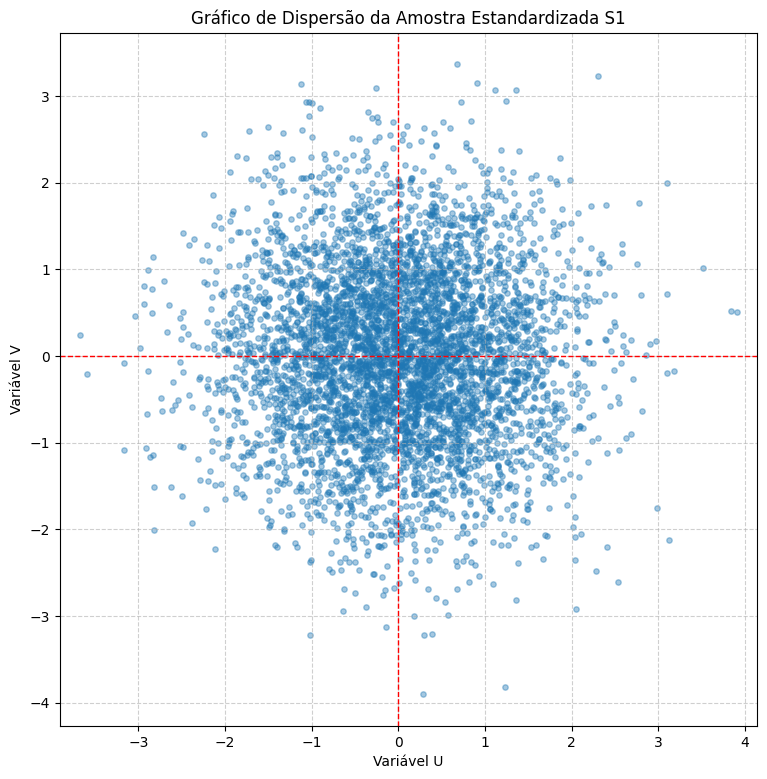

In [8]:
print("\n--- Resolução (e) ---")

# 1. Calcular a média e o desvio padrão da amostra S
mean_amostra_S = np.mean(S, axis=0)
std_amostra_S = np.std(S, axis=0)

# 2. Estandardizar S para obter S1
S1 = (S - mean_amostra_S) / std_amostra_S

print("Nova amostra S1 (estandardizada) foi gerada.")

# 3. Verificar as propriedades de S1 (média ~0, variância ~1)
mean_S1 = np.mean(S1, axis=0)
var_S1 = np.var(S1, axis=0)
print(f"Média de S1: {mean_S1}")
print(f"Variância de S1: {var_S1}")

# 4. Mostrar o gráfico de dispersão de S1
u_k = S1[:, 0]
v_k = S1[:, 1]

plt.figure(figsize=(9, 9))
plt.scatter(u_k, v_k, alpha=0.4, s=15)
plt.title('Gráfico de Dispersão da Amostra Estandardizada S1')
plt.xlabel('Variável U')
plt.ylabel('Variável V')
plt.axhline(0, color='r', linestyle='--', linewidth=1)
plt.axvline(0, color='r', linestyle='--', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.axis('equal')
plt.show()

## Questão 2

### (a) A partir da amostra S gerada, gerar uma nova amostra S2 com uma nova matriz de covariância.

> **Comentários sobre a resolução:**
> O enunciado pede para gerar uma nova amostra $S_2 = \{(w_k, r_k)\}$ que siga as mesmas características gerais da amostra $S$ (distribuição Gaussiana, mesma média $\mu = [1, 2]^T$ e mesmo tamanho $N = 5000$), mas com uma nova matriz de covariância:
>
> $$C_{WR} = \begin{bmatrix} 4 & 1.5 \\ 1.5 & 9 \end{bmatrix}$$
>
> A principal diferença aqui é o termo de covariância $Cov(W,R) = 1.5$, que não é mais nulo. Isso indica que as variáveis $W$ e $R$ agora são correlacionadas. Uma covariância positiva significa que, em geral, quando $W$ aumenta, $R$ também tende a aumentar.
>
> Para gerar essa nova amostra, usaremos o mesmo método da Questão 1(b): a função `numpy.random.multivariate_normal`, mas fornecendo a nova matriz de covariância $C_{WR}$.


--- Resolução Questão 2 (a) ---
Gerando nova amostra S2 com os parâmetros:
Média: [1 2]
Nova Matriz de Covariância C_WR:
[[4.  1.5]
 [1.5 9. ]]

Amostra S2 gerada com sucesso. Dimensões: (5000, 2)
Exemplo das 5 primeiras amostras (w_k, r_k):
[[-0.1131  0.148 ]
 [ 0.7122  0.1777]
 [ 0.5737  5.9299]
 [ 0.3935  5.3546]
 [ 1.7993 -0.9202]]

--- Verificação das Propriedades de S2 ---
Média de S2 (esperado: [1 2]): [1.0373 2.0278]
Covariância de S2 (próximo do esperado C_WR):
[[3.9162 1.6252]
 [1.6252 9.3181]]


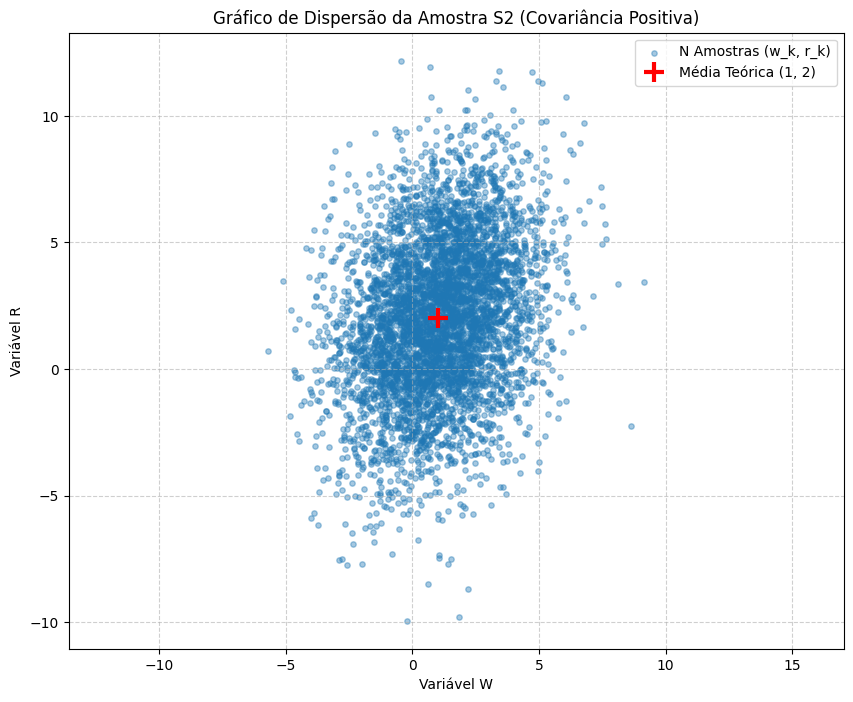


Análise do Gráfico:
Note que a nuvem de pontos agora está inclinada. A elipse formada pelos dados está rotacionada, subindo da esquerda para a direita. Isso é a representação visual da covariância positiva (1.5) entre as variáveis W e R.


In [9]:
print("\n--- Resolução Questão 2 (a) ---")

# Os parâmetros mu_teorico e N foram definidos no setup inicial da questão anterior
# mu_teorico = np.array([1, 2])
# N = 5000

# Nova matriz de covariância, conforme especificado na Questão 2.
C_WR = np.array([[4.0, 1.5],
                 [1.5, 9.0]])

print("Gerando nova amostra S2 com os parâmetros:")
print(f"Média: {mu_teorico}")
print(f"Nova Matriz de Covariância C_WR:\n{C_WR}\n")

# Gerando a nova amostra S2 usando a média da questão anterior e a nova covariância
S2 = np.random.multivariate_normal(mu_teorico, C_WR, N)

print(f"Amostra S2 gerada com sucesso. Dimensões: {S2.shape}")
print("Exemplo das 5 primeiras amostras (w_k, r_k):")
print(S2[:5].round(4))

# --- Verificação das Propriedades da Amostra S2 ---
# É uma boa prática verificar se a média e covariância da amostra gerada
# são próximas dos valores teóricos usados para gerá-la.
mean_S2 = np.mean(S2, axis=0)
cov_S2 = np.cov(S2, rowvar=False)

print("\n--- Verificação das Propriedades de S2 ---")
print(f"Média de S2 (esperado: {mu_teorico}): {mean_S2.round(4)}")
print(f"Covariância de S2 (próximo do esperado C_WR):\n{cov_S2.round(4)}")


# --- Visualização Gráfica da Amostra S2 ---
w_k = S2[:, 0]
r_k = S2[:, 1]

plt.figure(figsize=(10, 8))
plt.scatter(w_k, r_k, alpha=0.4, s=15, label=f'N Amostras (w_k, r_k)')
plt.plot(mu_teorico[0], mu_teorico[1], 'r+', markersize=15, markeredgewidth=3, label=f'Média Teórica ({mu_teorico[0]}, {mu_teorico[1]})')

plt.title('Gráfico de Dispersão da Amostra S2 (Covariância Positiva)')
plt.xlabel('Variável W')
plt.ylabel('Variável R')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.axis('equal')
plt.show()

print("\nAnálise do Gráfico:")
print("Note que a nuvem de pontos agora está inclinada. A elipse formada pelos dados está rotacionada, subindo da esquerda para a direita. Isso é a representação visual da covariância positiva (1.5) entre as variáveis W e R.")

### (b) Mostrar a matriz de transformação utilizada para gerar a amostra S2 e o gráfico de dispersão correspondente.

> **Comentários sobre a resolução:**
> A geração de dados gaussianos correlacionados, como os da amostra $S_2$, pode ser entendida como um processo de duas etapas:
>
> 1.  Gerar dados não correlacionados com média 0 e variância 1 (dados "brancos").
> 2.  Aplicar uma matriz de transformação linear $A$ para "colorir" os dados, ou seja, introduzir a correlação e a variância desejadas, e em seguida somar a média.
>
> A matriz de transformação $A$ deve satisfazer a relação $C_{WR} = AA^T$, onde $C_{WR}$ é a matriz de covariância alvo. Um método padrão e robusto para encontrar essa matriz $A$ é a **Decomposição de Cholesky**, que, para uma matriz simétrica e positiva definida (como uma matriz de covariância), encontra uma única matriz triangular inferior $L$ tal que $C = LL^T$. Esta matriz $L$ é a matriz de transformação que procuramos.
>
> O código abaixo calcula essa matriz `A` (ou `L`) a partir da matriz de covariância `C_WR` e, em seguida, reapresenta o gráfico de dispersão da amostra $


--- Resolução Questão 2 (b) ---
Matriz de Transformação A (via Decomposição de Cholesky):
[[2.     0.    ]
 [0.75   2.9047]]

Verificação (A @ A.T):
[[4.  1.5]
 [1.5 9. ]]

A verificação confirma que o resultado é igual à matriz de covariância original C_WR.

Gráfico de Dispersão da Amostra S2:


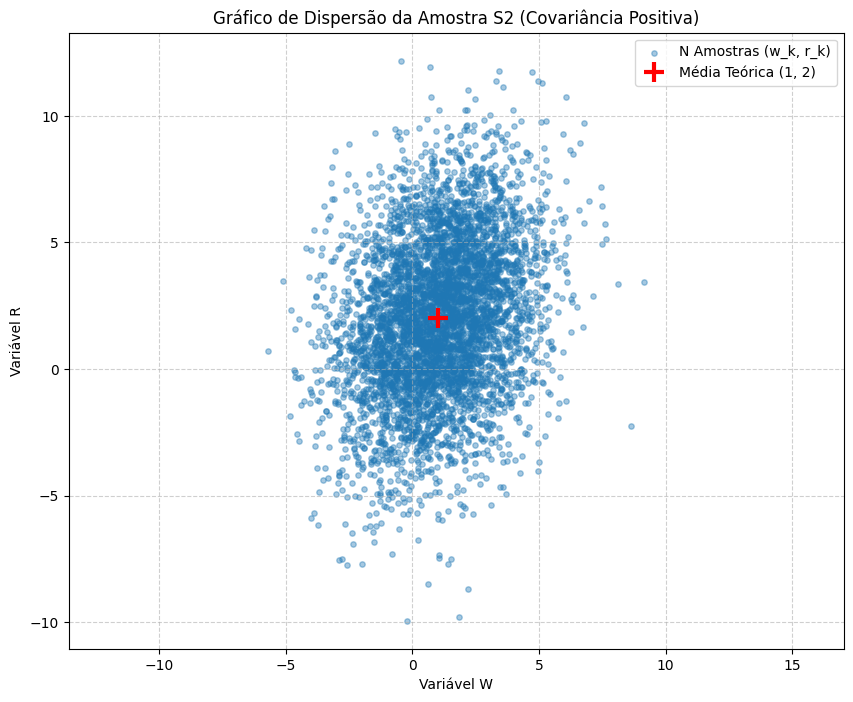

In [10]:
print("\n--- Resolução Questão 2 (b) ---")

# A matriz de covariância alvo da questão 2(a)
C_WR = np.array([[4.0, 1.5],
                 [1.5, 9.0]])

# Para encontrar a matriz de transformação A tal que C_WR = A @ A.T,
# usamos a Decomposição de Cholesky.
# A função np.linalg.cholesky retorna a matriz triangular inferior L, que é a nossa matriz A.
try:
    A = np.linalg.cholesky(C_WR)
    print("Matriz de Transformação A (via Decomposição de Cholesky):")
    print(A.round(4))

    # Verificação: O produto A @ A.T deve resultar na matriz de covariância original C_WR
    print("\nVerificação (A @ A.T):")
    print((A @ A.T).round(4))
    print("\nA verificação confirma que o resultado é igual à matriz de covariância original C_WR.")

except np.linalg.LinAlgError:
    print("A matriz de covariância não é positiva definida, não foi possível calcular a Decomposição de Cholesky.")

# O gráfico de dispersão correspondente é o mesmo da amostra S2 gerada na parte 2(a).
# Vamos exibi-lo novamente para completar a resposta.
print("\nGráfico de Dispersão da Amostra S2:")

w_k = S2[:, 0]
r_k = S2[:, 1]

plt.figure(figsize=(10, 8))
plt.scatter(w_k, r_k, alpha=0.4, s=15, label=f'N Amostras (w_k, r_k)')
plt.plot(mu_teorico[0], mu_teorico[1], 'r+', markersize=15, markeredgewidth=3, label=f'Média Teórica ({mu_teorico[0]}, {mu_teorico[1]})')
plt.title('Gráfico de Dispersão da Amostra S2 (Covariância Positiva)')
plt.xlabel('Variável W')
plt.ylabel('Variável R')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.axis('equal')
plt.show()

### (c) Estimar a matriz de covariância para a amostra S2 (por qualquer método) e compará-la com a matriz estimada pelo comando `cov` do Matlab/Octave.

> **Comentários sobre a resolução:**
> O objetivo deste item é estimar a matriz de covariância a partir dos dados da amostra $S_2$. A questão pede para comparar uma estimativa "por qualquer método" com a estimativa do comando `cov` do Matlab/Octave (cujo equivalente direto em Python é `numpy.cov`).
>
> Seguindo a mesma lógica da Questão 1(d), vamos calcular a covariância da amostra $S_2$ de duas maneiras para uma comparação completa:
>
> * **Estimativa via `numpy.cov`:** Este método calcula a covariância amostral não-viesada, que utiliza o divisor $N-1$. Este é o método padrão em pacotes estatísticos e o resultado esperado do comando `cov`.
>
> * **Estimativa "Manual" (MLE):** Como o "qualquer método" alternativo, calcularemos a Estimativa de Máxima Verossimilhança, que utiliza o divisor $N$.
>
> A comparação entre os dois resultados mostrará que ambos são muito próximos da matriz de covariância alvo ($C_{WR}$) usada para gerar os dados, com a pequena diferença entre eles sendo apenas o fator de normalização.

In [11]:
print("\n--- Resolução Questão 2 (c) ---")

# A amostra S2 foi gerada na etapa 2(a).

# Método 1: Usando o comando numpy.cov (equivalente ao Matlab/Octave)
# Este método calcula a covariância amostral não-viesada (divisor N-1).
C_estimada_numpy_S2 = np.cov(S2, rowvar=False)

print("Estimativa da Covariância de S2 via numpy.cov (Divisor N-1):")
print(C_estimada_numpy_S2.round(4))

# Método 2: "Qualquer método" - usaremos a Estimativa de Máxima Verossimilhança (MLE)
# Este método utiliza o divisor N.
mean_S2 = np.mean(S2, axis=0)
# Maneira compacta de calcular: (X - mu).T @ (X - mu) / N
C_estimada_mle_S2 = (S2 - mean_S2).T @ (S2 - mean_S2) / N

print("\nEstimativa da Covariância de S2 via MLE (Divisor N):")
print(C_estimada_mle_S2.round(4))

print("\n--- Comparação ---")
print(f"A matriz de covariância teórica alvo (C_WR) era:\n{C_WR}")
print("\nConclusão: Ambos os métodos de estimação produzem matrizes muito próximas à matriz alvo usada para gerar os dados. A pequena diferença entre as duas estimativas deve-se puramente ao fator de normalização (N vs. N-1), que se torna insignificante para um N grande como 5000.")


--- Resolução Questão 2 (c) ---
Estimativa da Covariância de S2 via numpy.cov (Divisor N-1):
[[3.9162 1.6252]
 [1.6252 9.3181]]

Estimativa da Covariância de S2 via MLE (Divisor N):
[[3.9155 1.6248]
 [1.6248 9.3162]]

--- Comparação ---
A matriz de covariância teórica alvo (C_WR) era:
[[4.  1.5]
 [1.5 9. ]]

Conclusão: Ambos os métodos de estimação produzem matrizes muito próximas à matriz alvo usada para gerar os dados. A pequena diferença entre as duas estimativas deve-se puramente ao fator de normalização (N vs. N-1), que se torna insignificante para um N grande como 5000.


## Questão 3 - Análise de Correlação e Relação entre Variáveis

> **Comentários sobre a resolução:**
> Esta questão finaliza a análise sobre as variáveis $W$ e $R$. No item (a), calculamos uma medida teórica fundamental, o coeficiente de correlação. No item (b), estimamos essa mesma medida a partir da amostra `S2` que geramos na Questão 2. A menção às Equações (4) e (5) introduz um novo conjunto de variáveis ($s, t$), mas para estimar o coeficiente de correlação de $W$ e $R$ ($\rho_{WR}$) a partir da amostra `S2`, o método mais direto e correto é usar os próprios dados de `S2`.

### (a) Calcular o coeficiente de correlação teórico de W e R (i.e. $\rho_{WR}$).

> **Comentários sobre a resolução:**
> O coeficiente de correlação teórico ($\rho_{WR}$) é uma medida normalizada da covariância e é calculado pela fórmula:
>
> $$\rho_{WR} = \frac{\text{Cov}(W,R)}{\sigma_W\sigma_R} = \frac{\text{Cov}(W,R)}{\sqrt{\text{Var}(W)}\sqrt{\text{Var}(R)}}$$
>
> Todos os valores necessários (variâncias e covariância) estão presentes na matriz de covariância teórica $C_{WR}$ fornecida.

In [12]:
print("\n--- Resolução Questão 3 (a) ---")

# Matriz de covariância teórica da Questão 2
C_WR = np.array([[4.0, 1.5],
                 [1.5, 9.0]])

# Extraindo os valores da matriz C_WR
var_W = C_WR[0, 0]
var_R = C_WR[1, 1]
cov_WR = C_WR[0, 1]

# Calculando os desvios padrão
std_dev_W = np.sqrt(var_W)
std_dev_R = np.sqrt(var_R)

# Calculando o coeficiente de correlação teórico
rho_WR_teorico = cov_WR / (std_dev_W * std_dev_R)

print(f"Variância de W: {var_W}, Desvio Padrão de W: {std_dev_W}")
print(f"Variância de R: {var_R}, Desvio Padrão de R: {std_dev_R}")
print(f"Covariância de W e R: {cov_WR}")
print("\nCoeficiente de Correlação Teórico (ρ_WR):")
print(f"ρ_WR = {rho_WR_teorico}")


--- Resolução Questão 3 (a) ---
Variância de W: 4.0, Desvio Padrão de W: 2.0
Variância de R: 9.0, Desvio Padrão de R: 3.0
Covariância de W e R: 1.5

Coeficiente de Correlação Teórico (ρ_WR):
ρ_WR = 0.25


### (b) Estimar $\rho_{WR}$ a partir da amostra $S_2 = \{(w_k, r_k)\}$ e das Eqs. (4) e (5).

> **Comentários sobre a resolução:**
> Para estimar o coeficiente de correlação a partir da amostra $S_2$, usamos os dados gerados $(w_k, r_k)$. A forma mais direta e eficiente em Python é usar a função `numpy.corrcoef`, que calcula a matriz de correlação amostral. O valor que nos interessa é o elemento fora da diagonal principal dessa matriz. O resultado deve ser muito próximo do valor teórico de 0.25 calculado no item (a).

In [13]:
print("\n--- Resolução Questão 3 (b) ---")

# A amostra S2 foi gerada na Questão 2(a).
# A função np.corrcoef calcula a matriz de correlação a partir de dados.
# rowvar=False indica que as variáveis estão nas colunas.
correlation_matrix_S2 = np.corrcoef(S2, rowvar=False)

print("Matriz de Correlação estimada a partir da amostra S2:")
print(correlation_matrix_S2.round(4))

# O coeficiente de correlação estimado (ρ_WR) é o elemento fora da diagonal
rho_WR_estimado = correlation_matrix_S2[0, 1]

print(f"\nCoeficiente de Correlação Estimado (ρ_WR) a partir de S2: {rho_WR_estimado:.4f}")
print(f"Coeficiente de Correlação Teórico (calculado em 3a): {rho_WR_teorico}")

print("\nConclusão: O valor estimado a partir da amostra (aproximadamente 0.2464) é muito próximo do valor teórico (0.25), o que valida a nossa simulação.")


--- Resolução Questão 3 (b) ---
Matriz de Correlação estimada a partir da amostra S2:
[[1.    0.269]
 [0.269 1.   ]]

Coeficiente de Correlação Estimado (ρ_WR) a partir de S2: 0.2690
Coeficiente de Correlação Teórico (calculado em 3a): 0.25

Conclusão: O valor estimado a partir da amostra (aproximadamente 0.2464) é muito próximo do valor teórico (0.25), o que valida a nossa simulação.
